In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
import os

from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, roc_curve

from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)

from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_pre
from tensorflow.keras.applications.densenet import preprocess_input as densenet_pre
from tensorflow.keras.applications.mobilenet import preprocess_input as mobilenet_pre
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_pre

In [3]:
preprocess_map = {
    'ResNet50': resnet_pre,
    'DenseNet121': densenet_pre,
    'MobileNet': mobilenet_pre,
    'vgg19': vgg_pre
}

In [4]:
MODEL_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/models'
LOG_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/logs'
VAL_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split/val'

models_info = {
    'ResNet50': 'ResNet50_best.keras',
    'DenseNet121': 'DenseNet121_best.keras',
    'MobileNet': 'MobileNet_best.keras',
    'vgg19': 'vgg19_best.keras'
}

In [5]:
# Load Training History
histories = {}
for model_name in models_info.keys():
    log_file = os.path.join(LOG_DIR, f"{model_name}_training_log.csv")
    if os.path.exists(log_file):
        histories[model_name] = pd.read_csv(log_file)
        print(f"Loaded {model_name}: {len(histories[model_name])} epochs")
    else:
        print(f"Log file not found: {model_name}")

Loaded ResNet50: 16 epochs
Loaded DenseNet121: 24 epochs
Loaded MobileNet: 30 epochs
Loaded vgg19: 18 epochs


In [6]:
# Extract Final Metrics
results = []
for model_name, history_df in histories.items():
    final_epoch = history_df.iloc[-1]
    best_val_acc_idx = history_df['val_accuracy'].idxmax()
    best_epoch = history_df.iloc[best_val_acc_idx]

    results.append({
        'Model': model_name,
        'Final Train Acc': final_epoch['accuracy'],
        'Final Val Acc': final_epoch['val_accuracy'],
        'Best Val Acc': best_epoch['val_accuracy'],
        'Best Epoch': best_val_acc_idx + 1,
        'Overfitting Gap': final_epoch['accuracy'] - final_epoch['val_accuracy'],
        'Final Train Loss': final_epoch['loss'],
        'Final Val Loss': final_epoch['val_loss']
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Best Val Acc', ascending=False)

print("\n" + results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
print(f" BEST MODEL: {best_model_name}")
print(f"   Validation Accuracy: {results_df.iloc[0]['Best Val Acc']:.4f}")
print(f"   Achieved at Epoch: {int(results_df.iloc[0]['Best Epoch'])}")


      Model  Final Train Acc  Final Val Acc  Best Val Acc  Best Epoch  Overfitting Gap  Final Train Loss  Final Val Loss
   ResNet50         0.946775       0.967557      0.967557           8        -0.020783          0.143929        0.106408
  MobileNet         0.943882       0.967557      0.967557          22        -0.023675          0.146856        0.112998
DenseNet121         0.906132       0.954198      0.959924          16        -0.048066          0.232674        0.147974
      vgg19         0.881689       0.929389      0.931298          10        -0.047700          0.286531        0.201247
 BEST MODEL: ResNet50
   Validation Accuracy: 0.9676
   Achieved at Epoch: 8


In [7]:
def get_best_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    J = tpr - fpr
    best_idx = np.argmax(J)
    return thresholds[best_idx]

In [8]:
def create_val_generator(preprocess_func, folder):
    return ImageDataGenerator(preprocessing_function=preprocess_func).flow_from_directory(
        folder,
        target_size=IMG_SIZE,
        batch_size=32,
        class_mode="binary",
        shuffle=False
    )

In [9]:
all_reports = []
IMG_SIZE = (224, 224)

for model_name, model_file in models_info.items():

    print(f"\n================ {model_name} =================")

    # Load model
    model_path = os.path.join(MODEL_DIR, model_file)
    model = load_model(model_path)

    # Create correct val generator for this model
    val_generator = create_val_generator(
        preprocess_map[model_name],
        VAL_DIR
    )

    # Get predictions
    y_prob = model.predict(val_generator).ravel()
    y_true = val_generator.classes

    # Get best threshold
    best_threshold = get_best_threshold(y_true, y_prob)

    # Binary predictions
    y_pred = (y_prob >= best_threshold).astype(int)

    # Report
    report = classification_report(y_true, y_pred, output_dict=True)

    print(f"Best Threshold: {best_threshold:.4f}")
    print(classification_report(y_true, y_pred, digits=4))

    all_reports.append({
        'Model': model_name,
        'Threshold': best_threshold,
        'Accuracy': report['accuracy'],
        'Normal F1': report['0']['f1-score'],
        'Pneumonia F1': report['1']['f1-score']
    })


================ ResNet50 =================
Found 524 images belonging to 2 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 141s 8s/step
Best Threshold: 0.6677
              precision    recall  f1-score   support

           0     0.8958    0.9556    0.9247       135
           1     0.9842    0.9614    0.9727       389

    accuracy                         0.9599       524
   macro avg     0.9400    0.9585    0.9487       524
weighted avg     0.9614    0.9599    0.9603       524


================ DenseNet121 =================
Found 524 images belonging to 2 classes.
17/17 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step
Best Threshold: 0.6488
              precision    recall  f1-score   support

           0     0.8591    0.9481    0.9014       135
           1     0.9813    0.9460    0.9634       389

    accuracy                         0.9466       524
   macro avg     0.9202    0.9471    0.9324       524
weighted avg     0.9498    0.9466    0.9474       524


================ MobileNet =================


In [10]:
reports_df = pd.DataFrame(all_reports)
reports_df = reports_df.sort_values('Accuracy', ascending=False)

print("\n=== CLASS-WISE RESULTS ===")
print(reports_df.to_string(index=False))


=== CLASS-WISE RESULTS ===
      Model  Threshold  Accuracy  Normal F1  Pneumonia F1
  MobileNet   0.610448  0.965649   0.934783      0.976684
   ResNet50   0.667741  0.959924   0.924731      0.972692
DenseNet121   0.648829  0.946565   0.901408      0.963351
      vgg19   0.510134  0.933206   0.882155      0.953395


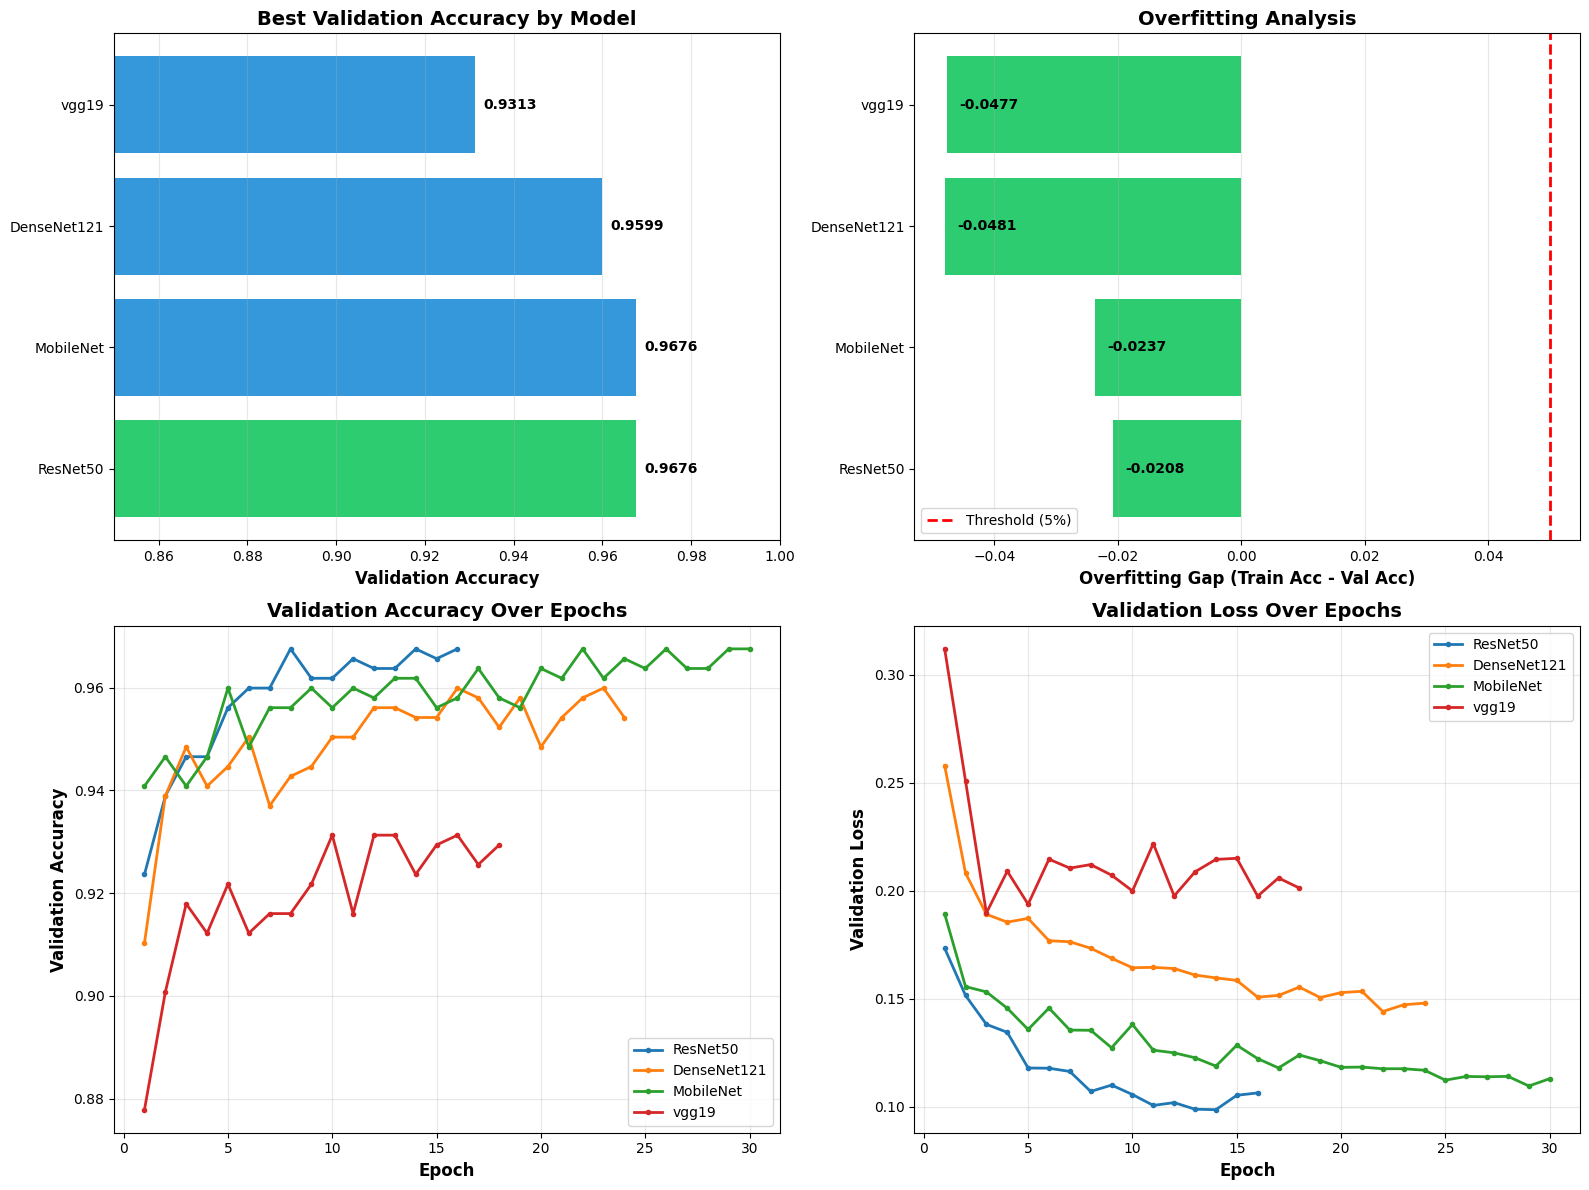

In [ ]:
# Validation Accuracy Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Best Validation Accuracy Bar Chart
ax = axes[0, 0]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in results_df['Model']]
bars = ax.barh(results_df['Model'], results_df['Best Val Acc'], color=colors)
ax.set_xlabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Best Validation Accuracy by Model', fontsize=14, fontweight='bold')
ax.set_xlim([0.85, 1.0])
for i, (model, acc) in enumerate(zip(results_df['Model'], results_df['Best Val Acc'])):
    ax.text(acc + 0.002, i, f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Plot 2: Overfitting Gap Comparison
ax = axes[0, 1]
colors = ['#e74c3c' if gap > 0.05 else '#2ecc71' for gap in results_df['Overfitting Gap']]
bars = ax.barh(results_df['Model'], results_df['Overfitting Gap'], color=colors)
ax.set_xlabel('Overfitting Gap (Train Acc - Val Acc)', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Analysis', fontsize=14, fontweight='bold')
ax.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Threshold (5%)')
for i, (model, gap) in enumerate(zip(results_df['Model'], results_df['Overfitting Gap'])):
    ax.text(gap + 0.002, i, f'{gap:.4f}', va='center', fontsize=10, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Plot 3: Training Curves - Accuracy
ax = axes[1, 0]
for model_name in histories.keys():
    epochs = range(1, len(histories[model_name]) + 1)
    ax.plot(epochs, histories[model_name]['val_accuracy'],
            marker='o', markersize=3, linewidth=2, label=model_name)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot 4: Training Curves - Loss
ax = axes[1, 1]
for model_name in histories.keys():
    epochs = range(1, len(histories[model_name]) + 1)
    ax.plot(epochs, histories[model_name]['val_loss'],
            marker='o', markersize=3, linewidth=2, label=model_name)
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax.set_title('Validation Loss Over Epochs', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

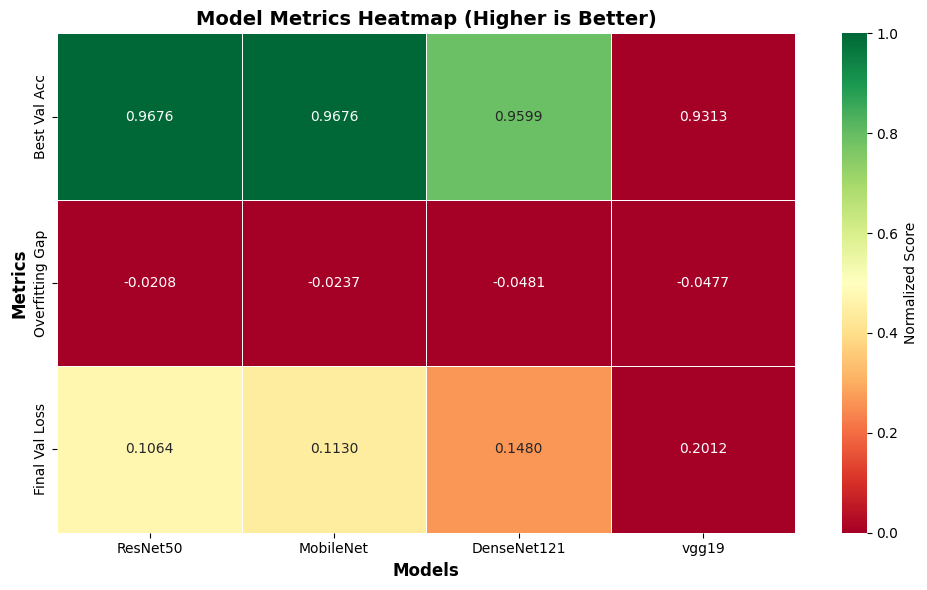

In [ ]:
# Detailed Metrics Heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data for heatmap
heatmap_data = results_df[['Model', 'Best Val Acc', 'Overfitting Gap', 'Final Val Loss']].set_index('Model')

# Normalize for better visualization
heatmap_normalized = heatmap_data.copy()
heatmap_normalized['Best Val Acc'] = (heatmap_data['Best Val Acc'] - heatmap_data['Best Val Acc'].min()) / \
                                      (heatmap_data['Best Val Acc'].max() - heatmap_data['Best Val Acc'].min())
heatmap_normalized['Overfitting Gap'] = 1 - (heatmap_data['Overfitting Gap'] / heatmap_data['Overfitting Gap'].max())
heatmap_normalized['Final Val Loss'] = 1 - (heatmap_data['Final Val Loss'] / heatmap_data['Final Val Loss'].max())

sns.heatmap(heatmap_normalized.T, annot=heatmap_data.T, fmt='.4f',
            cmap='RdYlGn', cbar_kws={'label': 'Normalized Score'},
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Model Metrics Heatmap (Higher is Better)', fontsize=14, fontweight='bold')
ax.set_ylabel('Metrics', fontsize=12, fontweight='bold')
ax.set_xlabel('Models', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

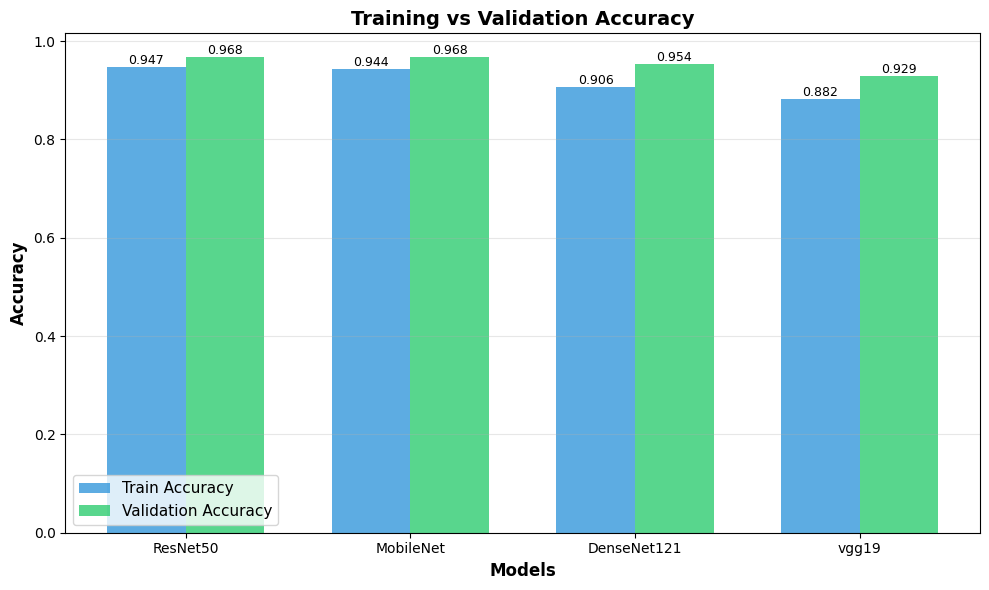

In [ ]:
# Train vs Val Accuracy
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['Final Train Acc'], width,
               label='Train Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['Final Val Acc'], width,
               label='Validation Accuracy', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Models', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
results_df.to_csv(os.path.join(MODEL_DIR, 'xray_models_summary.csv'), index=False)

In [ ]:
# Best Model Selection Criteria
print(f"\n1. Highest Validation Accuracy: {results_df.iloc[0]['Model']} ({results_df.iloc[0]['Best Val Acc']:.4f})")
print(f"2. Lowest Overfitting: {results_df.loc[results_df['Overfitting Gap'].idxmin(), 'Model']} " +
      f"(Gap: {results_df['Overfitting Gap'].min():.4f})")
print(f"3. Lowest Validation Loss: {results_df.loc[results_df['Final Val Loss'].idxmin(), 'Model']} " +
      f"(Loss: {results_df['Final Val Loss'].min():.4f})")


1. Highest Validation Accuracy: ResNet50 (0.9676)
2. Lowest Overfitting: DenseNet121 (Gap: -0.0481)
3. Lowest Validation Loss: ResNet50 (Loss: 0.1064)


In [ ]:
print(f"\nSelected Model for Fusion: {best_model_name}")
print(f"\nReason:")
print(f"  Highest validation accuracy: {results_df.iloc[0]['Best Val Acc']:.4f}")
print(f"  Overfitting gap: {results_df.iloc[0]['Overfitting Gap']:.4f}")
print(f"  Best epoch: {int(results_df.iloc[0]['Best Epoch'])}")

print(f"\nModel Path: {os.path.join(MODEL_DIR, models_info[best_model_name])}")



Selected Model for Fusion: ResNet50

Reason:
  Highest validation accuracy: 0.9676
  Overfitting gap: -0.0208
  Best epoch: 8

Model Path: /content/drive/MyDrive/IIT/FYP/Implementation/models/ResNet50_best.keras


###RESNET50 — UNIMODAL TEST EVALUATION

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/IIT/FYP/Implementation/models/ResNet50_best.keras'
SPLIT_TEST_DIR = '/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split/test'
SPLIT_VAL_DIR ='/content/drive/MyDrive/IIT/FYP/Implementation/data/Chest_Xray/chest_xray_split/val'

In [ ]:
IMG_SIZE  = (224, 224)

# Load model
model = keras.models.load_model(MODEL_PATH)

# Val generator (for Youden's J threshold)
val_gen = ImageDataGenerator(preprocessing_function=resnet_preprocess) \
          .flow_from_directory(
              SPLIT_VAL_DIR,
              target_size=IMG_SIZE,
              batch_size=32,
              class_mode='binary',
              shuffle=False
          )

Found 524 images belonging to 2 classes.


In [ ]:
# Test generator
test_gen = ImageDataGenerator(preprocessing_function=resnet_preprocess) \
           .flow_from_directory(
               SPLIT_TEST_DIR,
               target_size=IMG_SIZE,
               batch_size=32,
               class_mode='binary',
               shuffle=False
           )

Found 624 images belonging to 2 classes.


In [ ]:
# Predict on val (for threshold tuning)
p_val  = model.predict(val_gen,  verbose=0).flatten()
y_val  = val_gen.classes

# Youden's J on VAL set
fpr_v, tpr_v, thresh_v = roc_curve(y_val, p_val)
j_scores    = tpr_v - fpr_v
best_idx    = np.argmax(j_scores)
THRESHOLD   = thresh_v[best_idx]

print(f"Optimal Threshold (Youden's J, Val): {THRESHOLD:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Optimal Threshold (Youden's J, Val): 0.6677


In [ ]:
# Predict on test
p_test = model.predict(test_gen, verbose=0).flatten()
y_test = test_gen.classes          # 0=NORMAL, 1=PNEUMONIA
y_pred = (p_test >= THRESHOLD).astype(int)

# Metrics
acc       = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, p_test)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [ ]:
print("=" * 45)
print(f"  ResNet50 — Test Set (threshold={THRESHOLD:.4f})")
print("=" * 45)
print(f"  Accuracy             : {acc:.4f}")
print(f"  Precision            : {precision:.4f}")
print(f"  Recall (Sensitivity) : {recall:.4f}")
print(f"  F1-Score             : {f1:.4f}")
print(f"  ROC-AUC              : {auc:.4f}")
print("=" * 45)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred,
                            target_names=["Normal", "Pneumonia"]))

  ResNet50 — Test Set (threshold=0.6677)
  Accuracy             : 0.8478
  Precision            : 0.8285
  Recall (Sensitivity) : 0.9538
  F1-Score             : 0.8868
  ROC-AUC              : 0.9524

--- Classification Report ---
              precision    recall  f1-score   support

      Normal       0.90      0.67      0.77       234
   Pneumonia       0.83      0.95      0.89       390

    accuracy                           0.85       624
   macro avg       0.86      0.81      0.83       624
weighted avg       0.85      0.85      0.84       624



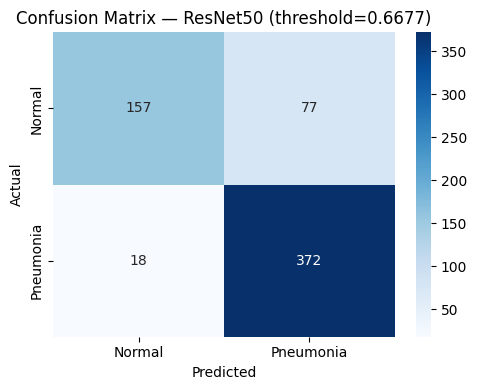

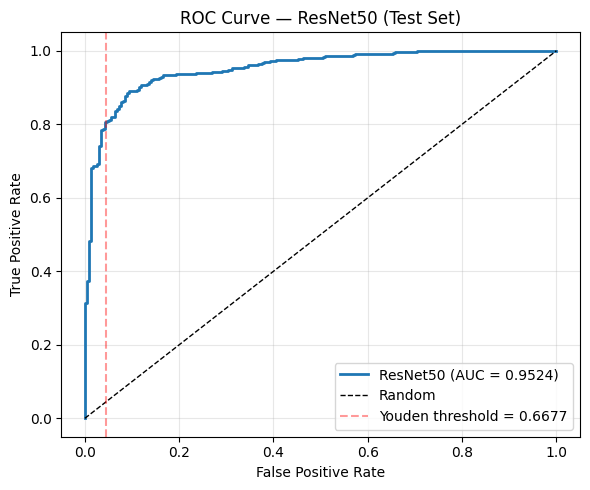

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal", "Pneumonia"],
            yticklabels=["Normal", "Pneumonia"])
plt.title(f"Confusion Matrix — ResNet50 (threshold={THRESHOLD:.4f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, p_test)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2,
         label=f'ResNet50 (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.axvline(x=fpr_v[best_idx], color='red', linestyle='--',
            alpha=0.4, label=f'Youden threshold = {THRESHOLD:.4f}')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ResNet50 (Test Set)")
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()